<a href="https://colab.research.google.com/github/kika-98/---/blob/main/Clusters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
from scipy import stats
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
import pylab as pl
import numpy as np
#доп установка seaborn и openpyxl

In [13]:
df = pd.read_excel('/content/sample_data/Chapter4_Geologic_DataSet.xlsx')
df.head()

,GR_API,"Bulk Density, gcc","Resistivity, ohm-m","Water Saturation, fraction","PhiH, ft","TOC, fraction","TVD, ft"
0,118,2.2096,23,0.13,23,0.077,10670
1,170,2.2185,21,0.17,20,0.073,9932
2,166,2.2260,14,0.20,21,0.070,9747
3,166,2.2260,14,0.20,21,0.070,9747
4,135,2.2303,22,0.16,24,0.068,9222


Гистограмма (частотная диаграмма, столбчатая диаграмма) - это разновидность научной и инженерной графики, которая позволяет визуально оценить базовые параметры распределения случайных величин. По оси Х откладывается значение параметра, по оси У число проб или замеров, находяшихся в диапазоне значений. Гистограмма позволяет оценить параметры распределения(это мин, среднее, макс и среднеквадратическое отклонение), его симметрию, баланс и т.д.

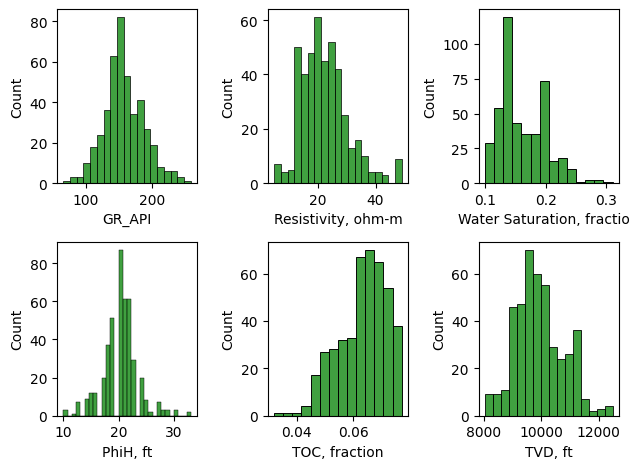

In [14]:
def data_hist(data):
    for i in range(0, 6):
        plt.subplot(2, 3, i+1)
        sns.histplot(df[data[i]], label='Clustering Data', color='g') #ругается на функцию distplot, меняю на histplot
    plt.tight_layout()

data = ['GR_API', 'Resistivity, ohm-m', 'Water Saturation, fraction', 'PhiH, ft', 'TOC, fraction', 'TVD, ft']
data_hist(data)

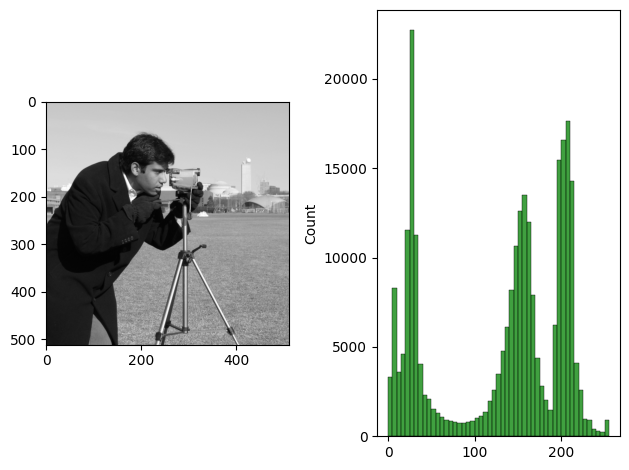

In [15]:
#Гистограмма как индикатор экспозиции изображения
#Построить диаграмму из библиотеки scikit-image
from skimage import data

img = data.camera()

def img_hist(img):
    img_flat = img.flatten() #разворачивает прямоугольную матрицу в векто
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.subplot(1, 2, 2)
    sns.histplot(img_flat, color='g')
    plt.tight_layout()

img_hist(img)

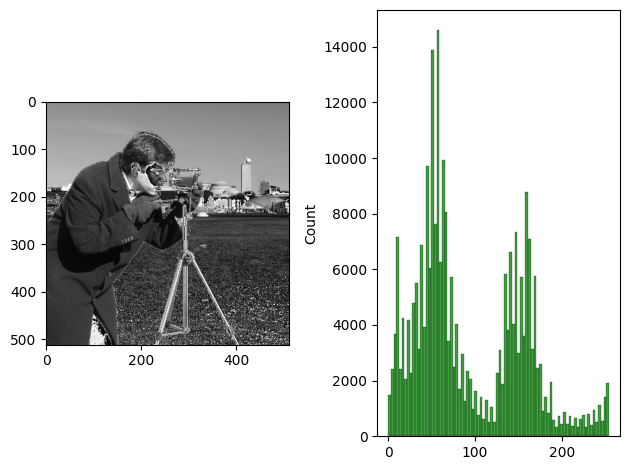

In [16]:
k = 2
img_2x = img * k

img_hist(img_2x)

<Axes: >

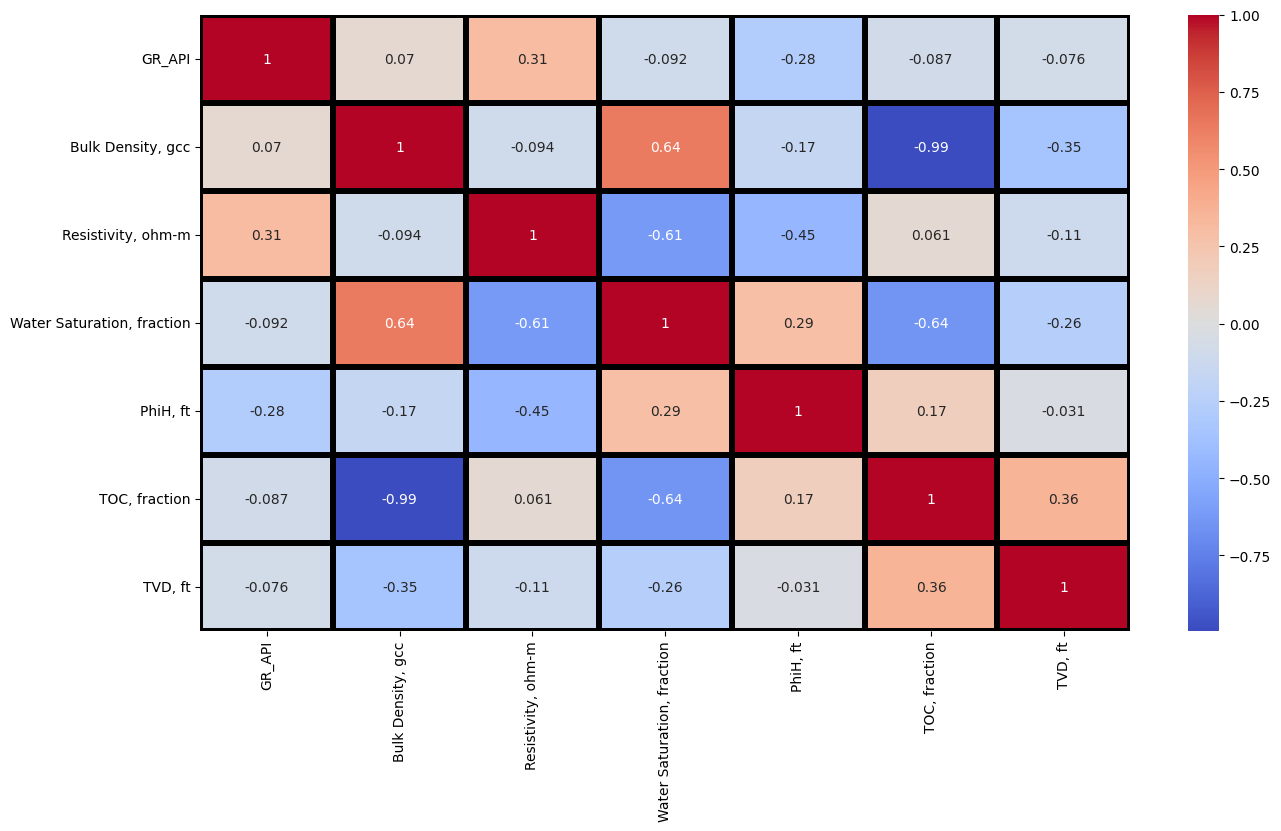

In [17]:
fig = plt.figure(figsize=(15,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True, linewidths=4, linecolor='black')

In [18]:
df.drop(['TOC, fraction'], axis=1, inplace=True)
df.describe()

,GR_API,"Bulk Density, gcc","Resistivity, ohm-m","Water Saturation, fraction","PhiH, ft","TVD, ft"
count,438.000000,438.000000,438.000000,438.000000,438.000000,438.000000
mean,157.972603,2.242265,22.438356,0.159863,20.283105,9935.125571
std,30.396528,0.019978,7.971895,0.037465,3.187825,827.981530
min,66.000000,2.209100,5.000000,0.100000,10.000000,8046.000000
25%,139.000000,2.226425,17.000000,0.130000,19.000000,9372.250000
50%,155.000000,2.239300,22.000000,0.150000,20.000000,9844.500000
75%,178.000000,2.255925,26.000000,0.190000,22.000000,10440.000000
max,259.000000,2.319600,49.000000,0.310000,33.000000,12474.000000


In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns)
df_scaled.describe()

,GR_API,"Bulk Density, gcc","Resistivity, ohm-m","Water Saturation, fraction","PhiH, ft","TVD, ft"
count,4.380000e+02,4.380000e+02,4.380000e+02,4.380000e+02,4.380000e+02,4.380000e+02
mean,-2.433366e-17,1.239394e-14,-2.108917e-16,-3.061985e-16,-4.582838e-16,1.622244e-17
std,1.001144e+00,1.001144e+00,1.001144e+00,1.001144e+00,1.001144e+00,1.001144e+00
min,-3.029220e+00,-1.661976e+00,-2.189981e+00,-1.599656e+00,-3.229431e+00,-2.284213e+00
25%,-6.248838e-01,-7.937814e-01,-6.829712e-01,-7.979978e-01,-4.029619e-01,-6.805940e-01
50%,-9.790598e-02,-1.485862e-01,-5.505058e-02,-2.635589e-01,-8.890975e-02,-1.095788e-01
75%,6.596246e-01,6.845299e-01,4.472859e-01,8.053189e-01,5.391946e-01,6.104626e-01
max,3.327450e+00,3.875427e+00,3.335721e+00,4.011952e+00,3.993769e+00,3.069848e+00


Text(0.5, 1.0, 'The Elbow Method showing the optimal k')

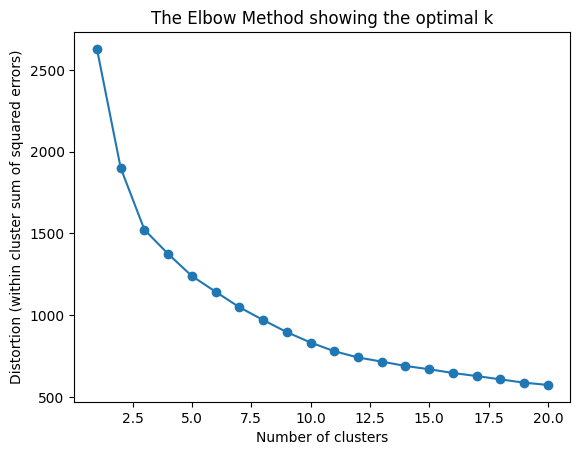

In [20]:
import matplotlib.pyplot as plt
distortions = []
for i in range (1,21):
    km = KMeans(n_clusters = i, random_state = 1000, init = 'k-means++', n_init = 500, max_iter = 500)
    km.fit(df_scaled)
    distortions.append(km.inertia_)
plt.plot(range(1,21), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion (within cluster sum of squared errors)')
plt.title('The Elbow Method showing the optimal k')

In [21]:
km = KMeans(n_clusters = 10, random_state = 1000, init = 'k-means++', n_init = 500, max_iter = 500)
km.fit(df_scaled)
labels = km.labels_
labels

array([2, 3, 3, 3, 8, 0, 9, 8, 5, 5, 4, 0, 4, 4, 5, 7, 2, 4, 2, 7, 7, 8,
       2, 1, 7, 3, 0, 3, 2, 3, 6, 4, 5, 4, 3, 6, 7, 5, 8, 0, 0, 4, 4, 3,
       7, 0, 1, 7, 2, 4, 7, 7, 8, 8, 8, 5, 2, 8, 5, 4, 3, 8, 2, 0, 3, 5,
       2, 9, 9, 5, 3, 3, 2, 8, 1, 9, 2, 4, 6, 7, 0, 3, 5, 5, 5, 2, 0, 4,
       7, 8, 7, 9, 2, 5, 5, 4, 4, 4, 4, 4, 0, 5, 5, 8, 3, 0, 8, 8, 6, 0,
       0, 1, 8, 8, 8, 7, 2, 1, 5, 7, 0, 4, 3, 5, 3, 7, 3, 7, 7, 5, 8, 7,
       0, 3, 7, 8, 4, 7, 2, 1, 2, 1, 6, 8, 3, 3, 2, 7, 0, 8, 4, 2, 4, 0,
       1, 8, 7, 2, 3, 7, 6, 5, 2, 7, 9, 3, 6, 0, 2, 7, 8, 3, 7, 4, 4, 3,
       2, 8, 2, 5, 2, 8, 6, 7, 4, 0, 0, 4, 3, 3, 4, 3, 2, 8, 3, 6, 6, 1,
       2, 9, 2, 9, 8, 5, 7, 7, 2, 2, 5, 2, 7, 7, 6, 8, 4, 3, 3, 4, 3, 1,
       4, 4, 4, 4, 0, 7, 7, 9, 6, 6, 6, 8, 5, 5, 2, 5, 3, 2, 3, 3, 7, 5,
       7, 9, 7, 6, 3, 3, 4, 3, 2, 1, 9, 7, 5, 5, 4, 3, 3, 4, 3, 3, 3, 3,
       4, 4, 5, 8, 5, 8, 7, 3, 3, 4, 3, 0, 2, 1, 8, 2, 3, 2, 3, 6, 7, 4,
       4, 0, 6, 0, 2, 2, 7, 1, 8, 5, 3, 3, 7, 7, 7,

In [22]:
df_new = pd.DataFrame(df, columns=df.columns[0:6])
df_new['Clusters'] = labels

dfsorted = df_new.sort_values(by='Clusters')

counts = dfsorted['Clusters'].value_counts()

group_means = dfsorted.groupby('Clusters').mean()

print(counts)
display(group_means)

dfsorted.to_csv('KM.csv', index=False)

Clusters
3    75
4    62
5    57
7    56
2    54
8    49
0    27
6    23
1    21
9    14
Name: count, dtype: int64


,GR_API,"Bulk Density, gcc","Resistivity, ohm-m","Water Saturation, fraction","PhiH, ft","TVD, ft"
Clusters,,,,,,
0,144.703704,2.253333,16.629630,0.195185,27.296296,9639.481481
1,213.428571,2.241110,25.333333,0.136667,15.333333,10592.000000
2,129.462963,2.224885,20.277778,0.131852,20.240741,11181.388889
3,154.426667,2.238265,15.853333,0.183600,20.906667,9672.533333
4,138.838710,2.265868,17.838710,0.195968,19.758065,9774.806452
5,186.210526,2.222981,25.421053,0.130702,20.982456,10441.807018
6,186.217391,2.279948,15.043478,0.238696,21.217391,9303.739130
7,166.910714,2.245191,32.464286,0.137500,18.125000,9303.553571
8,133.265306,2.225369,25.265306,0.131224,21.387755,9628.653061


In [30]:
txt = """
Для завершения работы необходимо установить класстеры,
соответствующие условно продуктивным породам.
В качестве критерия продуктивности устанавливается значение
TOC>=mean(TOC).
Дать интерпретацию полученным результатам в \"Выводе\".
"""
print(txt)
print('Прочитаем таблицу с диска для получения значений TOC')
df_reserve = pd.read_excel('/content/sample_data/Chapter4_Geologic_DataSet.xlsx')
df_reserve['clusters'] = labels
porog_TOC = df_reserve['TOC, fraction'].mean()
print('porog_TOC',porog_TOC)

df_reserve.head()



Для завершения работы необходимо установить класстеры,
соответствующие условно продуктивным породам.
В качестве критерия продуктивности устанавливается значение 
TOC>=mean(TOC). 
Дать интерпретацию полученным результатам в "Выводе".

Прочитаем таблицу с диска для получения значений TOC
porog_TOC 0.06322146118721461


,GR_API,"Bulk Density, gcc","Resistivity, ohm-m","Water Saturation, fraction","PhiH, ft","TOC, fraction","TVD, ft",clusters
0,118,2.2096,23,0.13,23,0.077,10670,2
1,170,2.2185,21,0.17,20,0.073,9932,3
2,166,2.2260,14,0.20,21,0.070,9747,3
3,166,2.2260,14,0.20,21,0.070,9747,3
4,135,2.2303,22,0.16,24,0.068,9222,8


In [37]:
productive = df_reserve['clusters'][df_reserve['TOC, fraction'] >= porog_TOC]
nonproductive = df_reserve['clusters'][df_reserve['TOC, fraction'] < porog_TOC]
#print(productive.unique())
#print(nonproductive.unique())
print(set(productive))
print(set(nonproductive))
print('unique productive',set(productive) - set(nonproductive))
print('unique productive',set(nonproductive) - set(productive ))

{0, 1, 2, 3, 5, 7, 8}
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
unique productive set()
unique productive {9, 4, 6}


## Выводы
в ходе работы была проведена классификация набора геофизических данных нефтегаового промысла с помощью метода класификаций "без учителя" (k-среднее). На основе анализа тепловой карты значений коэффициента кореляций Пирсона было установленно,что предиктор "TOC" (содержание органического вещества) сильно сколлирован с плотностью породы,на основе чего TOC не был использован для обучения модели.
Построением "графика локтя",демонстрирующего соотношение между количеством кластеров и ошибкой(разбросом относительно средних значений параметра внутри кластера) выбрано 10 кластеров.
В качестве порогового значения парамера, разделяющего условно "продуктивную" и "непродуктивную" толщи установленно среднее значение TOC.
На этом основании к "продуктивным" отнесены кластеры {0, 1, 2, 3, 5, 7, 8},а к "непродуктивным" {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
Уникальный класс,встречающийся только в продуктивных (коллектор)
это (),уникальный флюдиоупор (покрышка) 9,4,6